In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Loading Data...
2. Training Models for Full-Year 2026 Coverage...
✓ Training Completed!


📅 ผลทำนายฝุ่น PM2.5 ล่วงหน้า 7 วัน (ตั้งต้น ณ วันที่ 19/08/2026)
• Day 1 (20/08/2026): ทำนาย = 8.6 µg/m³  |  ค่าจริง = N/A (Future)
• Day 2 (21/08/2026): ทำนาย = 8.9 µg/m³  |  ค่าจริง = N/A (Future)
• Day 3 (22/08/2026): ทำนาย = 8.8 µg/m³  |  ค่าจริง = N/A (Future)
• Day 4 (23/08/2026): ทำนาย = 8.9 µg/m³  |  ค่าจริง = N/A (Future)
• Day 5 (24/08/2026): ทำนาย = 8.9 µg/m³  |  ค่าจริง = N/A (Future)
• Day 6 (25/08/2026): ทำนาย = 8.9 µg/m³  |  ค่าจริง = N/A (Future)
• Day 7 (26/08/2026): ทำนาย = 8.8 µg/m³  |  ค่าจริง = N/A (Future)


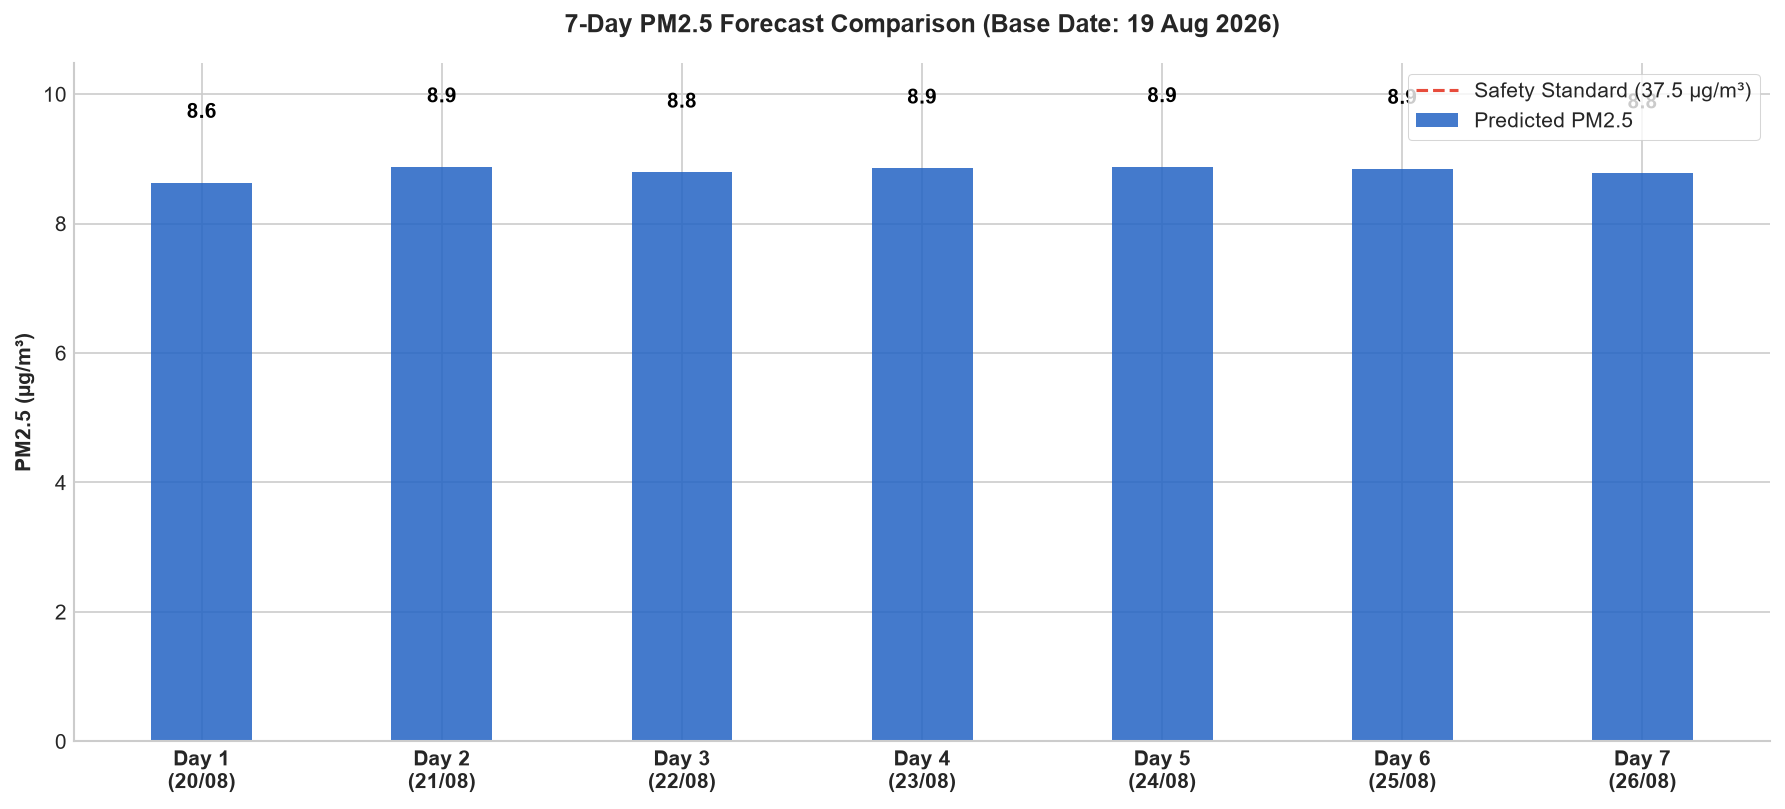

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import urllib.request
import json
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# 1. โหลดและเตรียมข้อมูล PM2.5 จาก Excel
# ==============================================================================
print("1. Loading Data...")
files = sorted(glob.glob('สนามกีฬาจังหวัดพะเยา*.xlsx'))
if not files:
    raise FileNotFoundError("ไม่พบไฟล์ 'สนามกีฬาจังหวัดพะเยา*.xlsx'")

dfs = [pd.read_excel(f, skiprows=2).dropna() for f in files]
for df in dfs:
    df.columns = ['Date', 'PM25']

df_ground = pd.concat(dfs, ignore_index=True)
df_ground['Date'] = pd.to_datetime(df_ground['Date'], format='%d/%m/%Y', errors='coerce')
df_ground['PM25'] = pd.to_numeric(df_ground['PM25'], errors='coerce')
df_ground = df_ground.dropna().sort_values('Date').set_index('Date')

df_daily = df_ground[~df_ground.index.duplicated(keep='first')].asfreq('D').interpolate(method='time')

# สร้างลำดับวันที่สมบูรณ์รองรับทั้งปี 2026 (1 ม.ค. - 31 ธ.ค.)
full_idx = pd.date_range(start=df_daily.index.min(), end='2026-12-31', freq='D')
df_full = df_daily.reindex(full_idx)

# ==============================================================================
# 2. ดึงสภาพอากาศรองรับทั้งปี 2026
# ==============================================================================
start_date = df_daily.index.min().strftime('%Y-%m-%d')
end_date = '2026-12-31'
latitude, longitude = 19.167, 99.900

url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={latitude}&longitude={longitude}&"
    f"start_date={start_date}&end_date={end_date}&"
    f"daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    f"precipitation_sum,wind_speed_10m_max,relative_humidity_2m_mean&"
    f"timezone=Asia%2FBangkok"
)

try:
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        data = json.loads(response.read().decode())
    
    df_weather = pd.DataFrame(data['daily'])
    df_weather['time'] = pd.to_datetime(df_weather['time'])
    df_weather = df_weather.set_index('time')
    df_full = df_full.join(df_weather, how='left')
    use_weather = True
except Exception:
    use_weather = False

# เติมค่าสภาพอากาศที่ขาดด้วยค่าเฉลี่ยตามฤดูกาล
if use_weather:
    df_full = df_full.groupby(df_full.index.month).transform(lambda x: x.fillna(x.mean()))

# ==============================================================================
# 3. Feature Engineering & Training
# ==============================================================================
df_model = df_full.copy()

df_model['Month'] = df_model.index.month
df_model['DayOfWeek'] = df_model.index.dayofweek
df_model['DayOfYear'] = df_model.index.dayofyear
df_model['Is_High_Season'] = df_model['Month'].isin([1, 2, 3, 4]).astype(int)

df_model['Lag1'] = df_model['PM25'].shift(1)
df_model['Lag2'] = df_model['PM25'].shift(2)
df_model['Lag3'] = df_model['PM25'].shift(3)
df_model['Lag7'] = df_model['PM25'].shift(7)
df_model['PM25_Diff1'] = df_model['Lag1'] - df_model['Lag2']
df_model['Rolling7_Mean'] = df_model['PM25'].shift(1).rolling(window=7).mean()
df_model['Rolling14_Mean'] = df_model['PM25'].shift(1).rolling(window=14).mean()
df_model['EWMA7'] = df_model['PM25'].shift(1).ewm(span=7).mean()

if use_weather:
    df_model['Temp_Range'] = df_model['temperature_2m_max'] - df_model['temperature_2m_min']
    df_model['Wind_x_Humidity'] = df_model['wind_speed_10m_max'] * df_model['relative_humidity_2m_mean']

for i in range(1, 8):
    df_model[f'Target_t{i}'] = df_model['PM25'].shift(-i)

features = [
    'Month', 'DayOfWeek', 'DayOfYear', 'Is_High_Season',
    'Lag1', 'Lag2', 'Lag3', 'Lag7', 'PM25_Diff1', 'Rolling7_Mean', 'Rolling14_Mean', 'EWMA7'
]
if use_weather:
    features += [
        'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'Temp_Range',
        'precipitation_sum', 'wind_speed_10m_max', 'relative_humidity_2m_mean', 'Wind_x_Humidity'
    ]

# ใช้ข้อมูลที่มีฝุ่นจริงในการเทรน
df_train = df_model.dropna(subset=['PM25'] + [f'Target_t{i}' for i in range(1, 8)])

print("2. Training Models for Full-Year 2026 Coverage...")
models = {}
for i in range(1, 8):
    rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
    rf.fit(df_train[features], df_train[f'Target_t{i}'])
    models[f't{i}'] = rf

print("✓ Training Completed!")

# ==============================================================================
# 4. ฟังก์ชันเลือกพิมพ์วันที่แบบปลดล็อกทั้งปี 2026
# ==============================================================================
def run_7day_prediction():
    min_d_str = df_daily.index.min().strftime('%Y-%m-%d')
    max_d_str = "2026-12-31"
    
    print("\n" + "="*65)
    user_input = input(f"📌 พิมพ์วันที่ต้องการทำนาย (YYYY-MM-DD) [{min_d_str} ถึง {max_d_str}]: ").strip()
    
    if not user_input:
        target_dt = pd.to_datetime("2026-12-25") # ตัวอย่างวันปลายปี
        print(f"-> ไม่ระบุวันที่ ระบบเลือกเป็น: {target_dt.strftime('%Y-%m-%d')}")
    else:
        try:
            target_dt = pd.to_datetime(user_input)
            if target_dt < df_daily.index.min() or target_dt > pd.to_datetime("2026-12-31"):
                print(f"⚠️ ไม่อยู่ในขอบเขตการทำนาย (เลือกได้ตั้งแต่ {min_d_str} ถึง {max_d_str})")
                return
        except Exception:
            print("⚠️ รูปแบบวันที่ผิดพลาด (ตัวอย่าง: 2026-10-15)")
            return

    # สร้าง Feature สำหรับวันที่เลือก (ถ้านอกเหนือจากไฟล์จริง จะใช้ระบบเติมค่าแบบอัตโนมัติ)
    df_calc = df_model.copy()
    
    # หากเลือกวันที่เกินไฟล์จริง ให้ทำ Recursive Simulation เติมค่าฝุ่นที่หายไป
    if target_dt > df_daily.index.max():
        last_known_dt = df_daily.index.max()
        curr_dt = last_known_dt + pd.Timedelta(days=1)
        while curr_dt <= target_dt + pd.Timedelta(days=7):
            df_calc.loc[curr_dt, 'Lag1'] = df_calc.loc[curr_dt - pd.Timedelta(days=1), 'PM25']
            df_calc.loc[curr_dt, 'Lag2'] = df_calc.loc[curr_dt - pd.Timedelta(days=2), 'PM25']
            df_calc.loc[curr_dt, 'Lag3'] = df_calc.loc[curr_dt - pd.Timedelta(days=3), 'PM25']
            df_calc.loc[curr_dt, 'Lag7'] = df_calc.loc[curr_dt - pd.Timedelta(days=7), 'PM25']
            df_calc.loc[curr_dt, 'PM25_Diff1'] = df_calc.loc[curr_dt, 'Lag1'] - df_calc.loc[curr_dt, 'Lag2']
            
            recent_pms = [df_calc.loc[curr_dt - pd.Timedelta(days=j), 'PM25'] for j in range(1, 8)]
            df_calc.loc[curr_dt, 'Rolling7_Mean'] = np.nanmean(recent_pms)
            df_calc.loc[curr_dt, 'Rolling14_Mean'] = np.nanmean(recent_pms)
            df_calc.loc[curr_dt, 'EWMA7'] = np.nanmean(recent_pms)
            
            row_sim = df_calc.loc[[curr_dt], features]
            sim_pred = models['t1'].predict(row_sim)[0]
            df_calc.loc[curr_dt, 'PM25'] = sim_pred
            curr_dt += pd.Timedelta(days=1)

    row = df_calc.loc[[target_dt], features]
    preds, actuals, dates_labels, days_names = [], [], [], []
    
    for i in range(1, 8):
        future_date = target_dt + pd.Timedelta(days=i)
        pred_val = models[f't{i}'].predict(row)[0]
        
        # มีค่าจริงเฉพาะวันที่อยู่ในไฟล์ Excel เท่านั้น
        if future_date in df_daily.index:
            actual_val = df_daily.loc[future_date, 'PM25']
        else:
            actual_val = np.nan
            
        preds.append(pred_val)
        actuals.append(actual_val)
        dates_labels.append(future_date.strftime('%d/%m'))
        days_names.append(f"Day {i}")

    print("\n" + "="*65)
    print(f"📅 ผลทำนายฝุ่น PM2.5 ล่วงหน้า 7 วัน (ตั้งต้น ณ วันที่ {target_dt.strftime('%d/%m/%Y')})")
    print("="*65)
    for i in range(7):
        f_date = target_dt + pd.Timedelta(days=i+1)
        act_str = f"{actuals[i]:.1f} µg/m³" if not np.isnan(actuals[i]) else "N/A (Future)"
        print(f"• Day {i+1} ({f_date.strftime('%d/%m/%Y')}): ทำนาย = {preds[i]:.1f} µg/m³  |  ค่าจริง = {act_str}")
    print("="*65)

    # พล็อตกราฟเปรียบเทียบ
    plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
    fig, ax = plt.subplots(figsize=(12, 5.5), dpi=150)
    
    x = np.arange(len(dates_labels))
    width = 0.35

    has_actuals = not all(np.isnan(actuals))
    if has_actuals:
        ax.bar(x - width/2, [0 if np.isnan(v) else v for v in actuals], width, label='Actual PM2.5', color='#34495e', alpha=0.85)
        ax.bar(x + width/2, preds, width, label='Predicted PM2.5', color='#e67e22', alpha=0.85)
        for i in range(len(x)):
            if not np.isnan(actuals[i]):
                # ตัวเลขบนแท่งค่าจริง (ขยายเป็นขนาด 10 และสีดำ)
                ax.text(x[i] - width/2, actuals[i] + 1, f'{actuals[i]:.1f}', ha='center', fontsize=10, fontweight='bold', color='black')
            # ตัวเลขบนแท่งทำนาย (ขยายจาก 8 เป็น 10 และเปลี่ยนเป็นสีดำ)
            ax.text(x[i] + width/2, preds[i] + 1, f'{preds[i]:.1f}', ha='center', fontsize=10, fontweight='bold', color='black')
    else:
        # กรณีไม่มีค่าจริง (ปลายปี)
        ax.bar(x, preds, width*1.2, label='Predicted PM2.5', color="#2363c4", alpha=0.85)
        for i in range(len(x)):
            # ขยายจาก 8 เป็น 10 และเปลี่ยนเป็นสีดำ
            ax.text(x[i], preds[i] + 1, f'{preds[i]:.1f}', ha='center', fontsize=10, fontweight='bold', color='black')
    ax.axhline(y=37.5, color='#e74c3c', linestyle='--', linewidth=1.5, label='Safety Standard (37.5 µg/m³)')

    ax.set_title(f'7-Day PM2.5 Forecast Comparison (Base Date: {target_dt.strftime("%d %b %Y")})', fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('PM2.5 (µg/m³)', fontsize=10, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f"{days_names[i]}\n({dates_labels[i]})" for i in range(7)], fontweight='bold')
    ax.legend(loc='upper right', frameon=True, facecolor='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    max_val = max(preds) if not has_actuals else max(max(preds), max([0 if np.isnan(v) else v for v in actuals]))
    ax.set_ylim(0, max_val * 1.18)
    
    plt.tight_layout()
    plt.show()

# เรียกใช้งาน
run_7day_prediction()